In [1]:
import torch
import torchvision
from torch import nn
from pathlib import Path

print("Pytorch Version: ", torch.__version__)
print("GPU enabled: ", torch.cuda.is_available())

Pytorch Version:  2.11.0+cu128
GPU enabled:  True


In [2]:
# this data is being stored in colab storage

import requests
import zipfile

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi" # here we use slash to join paths but it only works if it is imported from pathlib

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [3]:
print(image_path)
print(image_path.exists()) # previously what I had done was trying to import dataset from my own PC's directory, but here is a limitation with colab as here we are using colabs storage so data must be stored and should be imported from colab, it can't access your local computer root directory.

data/pizza_steak_sushi
True


In [4]:
import os # as we all know "os" is used for performing low level operations, like memory, getting current directory etc

def walk_thru_directory(dir_path):
    "we are creating this function, so that we can read our directory data, and build up better intuitions in terms of terminal look"
    
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
        




walk_thru_directory(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.


### this looks interesting as here we get looks of total counts

In [5]:
# now let's setup train and test directory path 


train_dataset_directory = image_path / "train"
test_dataset_directory = image_path / "test"

train_dataset_directory, test_dataset_directory

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

[PosixPath('data/pizza_steak_sushi/test/sushi/1742201.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/1987407.jpg'), PosixPath('data/pizza_steak_sushi/test/sushi/479711.jpg')]
data/pizza_steak_sushi/train/pizza/2190018.jpg
Image Path:  data/pizza_steak_sushi/train/pizza/2190018.jpg
Img class:  pizza
Width:  512
Height:  512


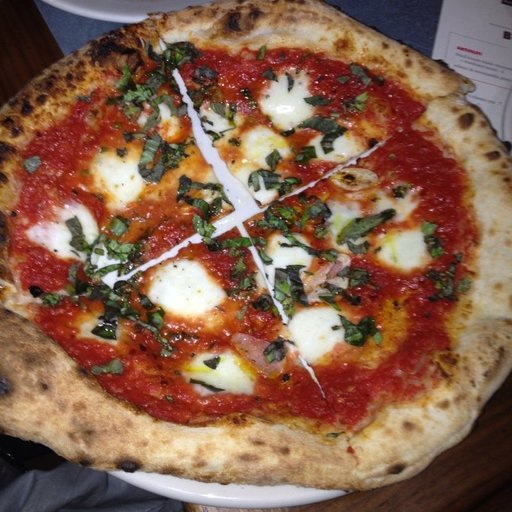

In [6]:
import random # its python bultin tool for generating random values
from PIL import Image # PIL stands for (Python Image Library)

img_path_lists = list(image_path.glob("*/*/*.jpg"))
print(img_path_lists[:3])

 
random_img_path = random.choice(img_path_lists) # here we are using .choice because we want it to randomly choose from the list.
print(random_img_path)

img_class = random_img_path.parent.stem

img = Image.open(random_img_path)

print("Image Path: ", random_img_path)
print("Img class: ", img_class)
print("Width: ", img.width)
print("Height: ", img.height)

img

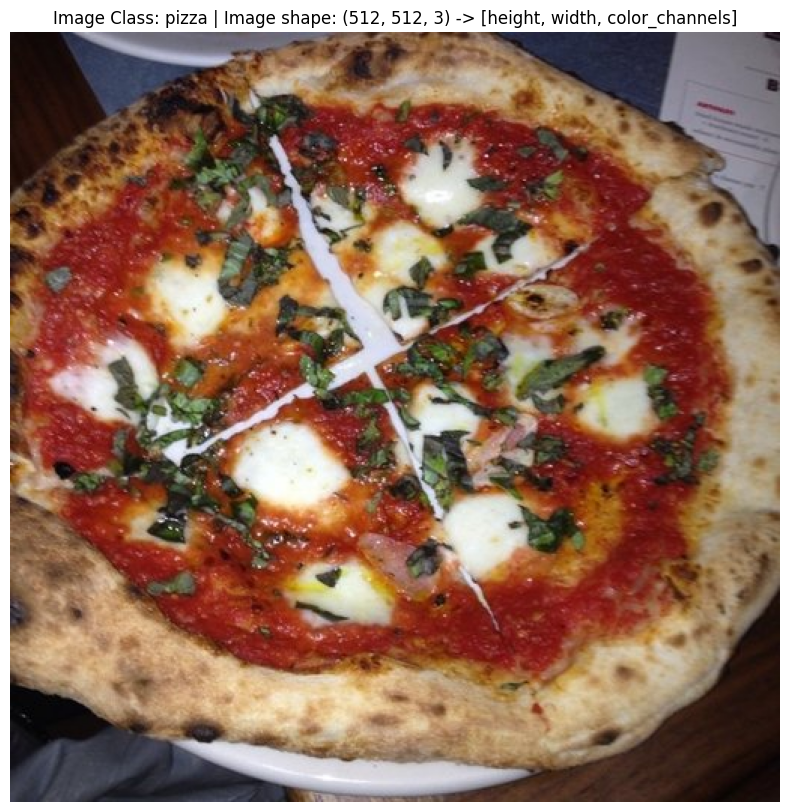

In [7]:
# lets do the same with matplotlib
import numpy as np
import matplotlib.pyplot as plt

img_to_np_array = np.asarray(img) # it converts img to numpy array into numerical form
plt.figure(figsize=(12,10))

plt.imshow(img_to_np_array)
plt.title(f"Image Class: {img_class} | Image shape: {img_to_np_array.shape} -> [height, width, color_channels]")
plt.axis("off")
plt.show()



In [8]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms # transorm is for converting the img data to pytorch tensors.

In [9]:
# here now we are going to create a pipile for data transformation, maybe its called preprocessing data phase.

data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)), # reducing img pexels to a fix size.
    transforms.RandomHorizontalFlip(p=0.5), # randomly flipping image on probability of 50%
    transforms.ToTensor() # to convert data into "Tensor"
])

data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
)

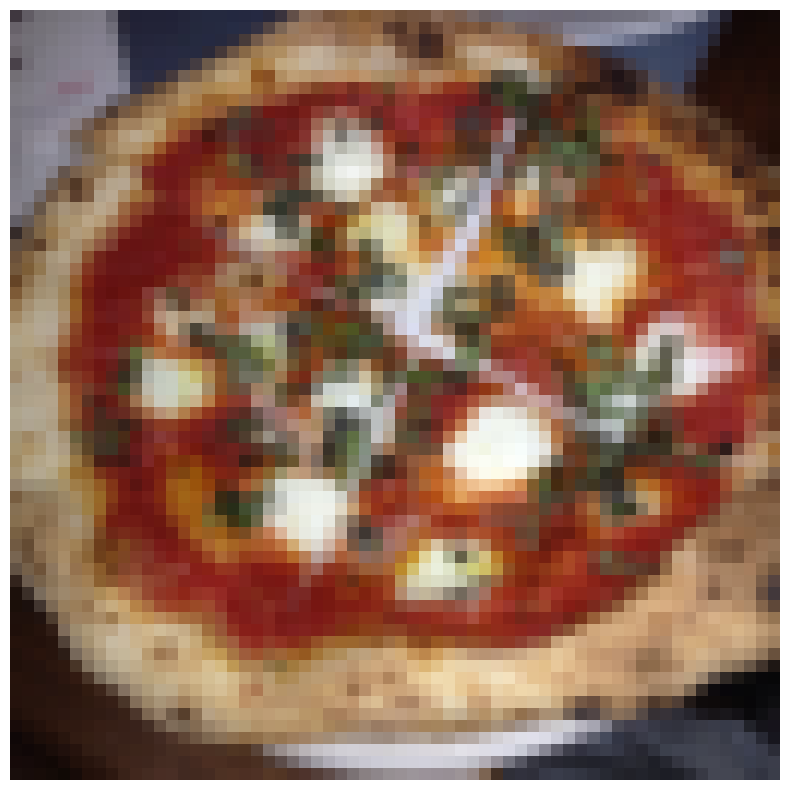

In [10]:
transformed_image = data_transform(img)

plt.figure(figsize=(10,10))

plt.imshow(transformed_image.permute(1, 2, 0)) # this permute is because when  our image was converted to tensor it's shape was (C,H,W) whereas matplotlib imshow expects shape (H,W,C), that's why we use permute to change the shape
plt.axis(False)
plt.show()

In [11]:
# so far we were only playing with single img from the list of data, now let's turn the complete dataset (test, train) into tensor for further training
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=train_dataset_directory,
    transform=data_transform,
    target_transform=None
)

test_dataset = datasets.ImageFolder(
    root=test_dataset_directory,
    transform=data_transform,
    target_transform=None
)

print(train_dataset.class_to_idx)
print(train_dataset[10], test_dataset[30])


{'pizza': 0, 'steak': 1, 'sushi': 2}
(tensor([[[0.8235, 0.8000, 0.7961,  ..., 0.8157, 0.8078, 0.8196],
         [0.7843, 0.7961, 0.8353,  ..., 0.8510, 0.8784, 0.8980],
         [0.8471, 0.8902, 0.9412,  ..., 0.9843, 0.9804, 0.9843],
         ...,
         [0.8039, 0.8549, 0.7882,  ..., 0.7882, 0.7529, 0.5412],
         [0.8078, 0.8196, 0.7922,  ..., 0.7176, 0.7608, 0.6784],
         [0.8471, 0.8824, 0.8784,  ..., 0.4902, 0.6627, 0.8196]],

        [[0.5882, 0.5686, 0.5647,  ..., 0.5882, 0.5725, 0.5882],
         [0.5333, 0.5569, 0.5961,  ..., 0.6824, 0.6980, 0.7098],
         [0.6039, 0.6549, 0.7059,  ..., 0.8706, 0.8667, 0.8627],
         ...,
         [0.5882, 0.6353, 0.5686,  ..., 0.4980, 0.4745, 0.3412],
         [0.6039, 0.6314, 0.6275,  ..., 0.4549, 0.4745, 0.4431],
         [0.6510, 0.7059, 0.7255,  ..., 0.2980, 0.4118, 0.5451]],

        [[0.2706, 0.2549, 0.2510,  ..., 0.3216, 0.3059, 0.3333],
         [0.2431, 0.2471, 0.2588,  ..., 0.4353, 0.4392, 0.4392],
         [0.2745, 0.

In [12]:
# another way of printing names of classes
class_names = train_dataset.classes
print(class_names)
print(f"length of train dataset: {len(train_dataset)}")
print(f"length of test dataset: {len(test_dataset)}")

['pizza', 'steak', 'sushi']
length of train dataset: 225
length of test dataset: 75


In [13]:
img, label = train_dataset[0][0], train_dataset[0][1]

img, label

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [14]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cec7cdb9940>,
 <torch.utils.data.dataloader.DataLoader at 0x7cec7bd2bed0>)

In [15]:
img, label = next(iter(train_dataloader)) 
print(img.shape, label.shape)
print(f"img: {img[:2]}") # it will print only 3 images
print(f"label: {label}") # print all labels

torch.Size([32, 3, 64, 64]) torch.Size([32])
img: tensor([[[[0.4627, 0.3961, 0.3843,  ..., 0.0824, 0.0667, 0.0510],
          [0.4627, 0.4196, 0.5137,  ..., 0.0902, 0.0549, 0.0275],
          [0.4627, 0.3843, 0.2824,  ..., 0.1020, 0.0745, 0.0471],
          ...,
          [0.5922, 0.5804, 0.5647,  ..., 0.5490, 0.5373, 0.5961],
          [0.6078, 0.6196, 0.6000,  ..., 0.5294, 0.5882, 0.6314],
          [0.5961, 0.6157, 0.6118,  ..., 0.5922, 0.5961, 0.2745]],

         [[0.4078, 0.3412, 0.3059,  ..., 0.0824, 0.0627, 0.0353],
          [0.4471, 0.3922, 0.4549,  ..., 0.0863, 0.0471, 0.0157],
          [0.4118, 0.3216, 0.2235,  ..., 0.0902, 0.0510, 0.0314],
          ...,
          [0.5725, 0.5569, 0.5412,  ..., 0.5412, 0.5412, 0.6471],
          [0.6000, 0.6118, 0.5765,  ..., 0.5451, 0.6667, 0.7647],
          [0.6000, 0.6078, 0.5882,  ..., 0.7098, 0.7373, 0.3255]],

         [[0.3294, 0.2824, 0.2314,  ..., 0.1294, 0.1059, 0.0745],
          [0.3882, 0.2941, 0.3373,  ..., 0.1255, 0.0863, 0

In [16]:
from typing import List

def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
    
    if seed:
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16, 8))

    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

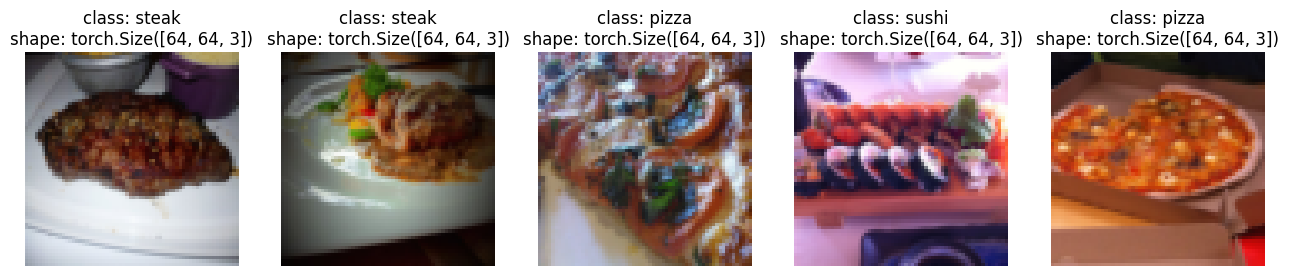

In [17]:
display_random_images(dataset=train_dataset, classes=class_names, n=5)

In [18]:
data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # how intense 
    transforms.ToTensor()
])

In [19]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


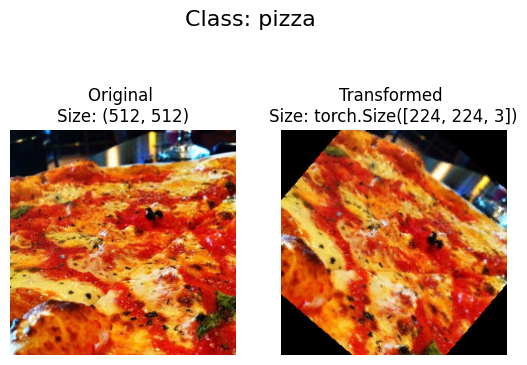

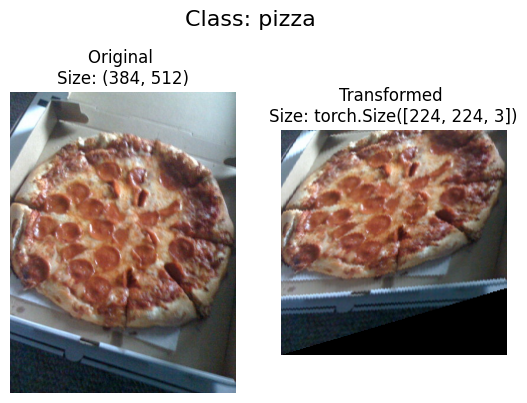

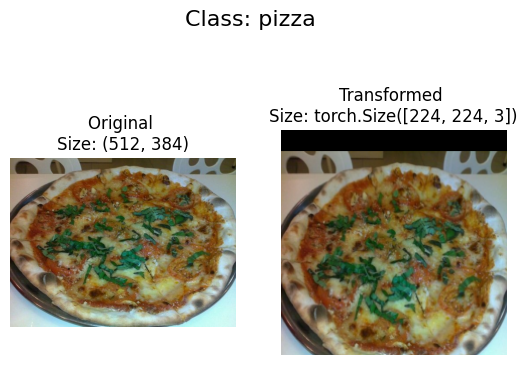

In [20]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))


# Plot random images
plot_transformed_images(
    image_paths=image_path_list,
    transform=data_transform,
    n=3,
    seed=None
)

In [21]:
class TinyVGGConvolutionalModel(nn.Module):
    def __init__(self, input_shape, output_shape, hidden_units):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16*16, out_features=output_shape)
        )
        
        
    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
    

modelV0 = TinyVGGConvolutionalModel(
    input_shape = 3, #  its the color channels
    hidden_units=10, 
    output_shape=len(class_names)
)

print(modelV0)
print(list(modelV0.parameters()))

TinyVGGConvolutionalModel(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)
[Parameter containing:
tensor([[[[ 7.9339e-02,  7.2246e-02,  1.6982e-01],
          [-8.7095e-02,  2.8519e-02,  6.8504e-02],
          [-9.7554e-02,  1.5949e-01,  1.4588e-01]],

         [[ 6.0569e-02, -3.7231e-02, -6.5166e-02],
        

In [22]:
print(img.shape)
print(img[0].shape)

y_logits = modelV0(img[0].unsqueeze(0))
y_preds = torch.argmax(y_logits, dim=1).item()

print(f"Logits: {y_logits}")
print(f"Model Pred: {class_names[y_preds]} V/S Actual: {class_names[label[0]]}")

torch.Size([32, 3, 64, 64])
torch.Size([3, 64, 64])
Logits: tensor([[-0.0060, -0.0629, -0.0018]], grad_fn=<AddmmBackward0>)
Model Pred: sushi V/S Actual: pizza


In [23]:
# Install torchinfo if it's not available, import it if it is
try: 
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo
    

from torchinfo import summary 
summary(
    modelV0, input_size=[1,3,64,64]
)

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGConvolutionalModel                [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def train_step(
        model: torch.nn.Module, 
        train_dataloader: torch.utils.data.DataLoader, 
        optimizer: torch.optim.Optimizer,
        loss_fn: torch.nn.Module =  nn.CrossEntropyLoss(),
        epoch: int = 5):
    
    model.train()
    
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        print(f"Batch: {batch} | Train Loss: {loss}")        
    
    
def test_step(
        model: torch.nn.Module, 
        test_dataloader: torch.utils.data.DataLoader, 
        optimizer: torch.optim.Optimizer,
        loss_fn: torch.nn.Module =  nn.CrossEntropyLoss(),
        epoch: int = 5):
    
    model.eval()
 
    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)
            
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            
            print(f"Batch: {batch} | Test Loss: {loss}")        
    
    

In [25]:
optimizer = torch.optim.Adam(params=modelV0.parameters(), lr=0.001)

In [26]:
def train(epochs:int, model, train_dataloader, optimizer):
    
    for epoch in range(epochs):
        print(f"Epoch: {epoch +1}")
        train_step(model=model, train_dataloader=train_dataloader, optimizer=optimizer)
        test_step(model=model, test_dataloader=test_dataloader, optimizer=optimizer)


train(epochs=100,model=modelV0, train_dataloader=train_dataloader, optimizer=optimizer )

Epoch: 1
Batch: 0 | Train Loss: 1.1034936904907227
Batch: 1 | Train Loss: 1.0924546718597412
Batch: 2 | Train Loss: 1.1097030639648438
Batch: 3 | Train Loss: 1.1175522804260254
Batch: 4 | Train Loss: 1.0857751369476318
Batch: 5 | Train Loss: 1.0953699350357056
Batch: 6 | Train Loss: 1.1103076934814453
Batch: 7 | Train Loss: 1.1854486465454102
Batch: 0 | Test Loss: 1.1038360595703125
Batch: 1 | Test Loss: 1.0998125076293945
Batch: 2 | Test Loss: 1.1051074266433716
Epoch: 2
Batch: 0 | Train Loss: 1.107403039932251
Batch: 1 | Train Loss: 1.0928895473480225
Batch: 2 | Train Loss: 1.0883128643035889
Batch: 3 | Train Loss: 1.102492094039917
Batch: 4 | Train Loss: 1.1029515266418457
Batch: 5 | Train Loss: 1.10860276222229
Batch: 6 | Train Loss: 1.1061646938323975
Batch: 7 | Train Loss: 1.1664296388626099
Batch: 0 | Test Loss: 1.0799891948699951
Batch: 1 | Test Loss: 1.092555284500122
Batch: 2 | Test Loss: 1.0967762470245361
Epoch: 3
Batch: 0 | Train Loss: 1.0985658168792725
Batch: 1 | Train L

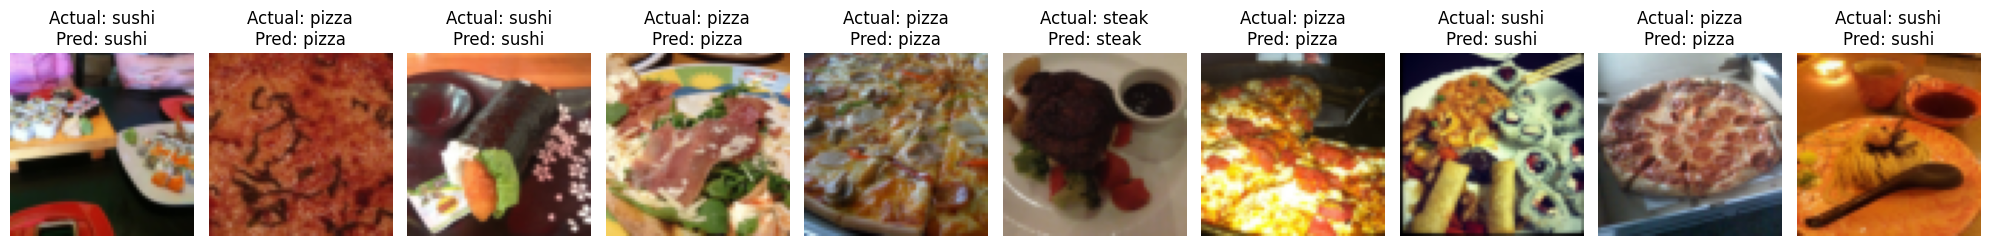

In [54]:
predictions = 10

with torch.inference_mode():

    # Get ONE batch
    X, y = next(iter(train_dataloader))

    X, y = X.to(device), y.to(device)

    # Create ONE figure containing all 10 images
    plt.figure(figsize=(20, 4))

    for i in range(predictions):

        # Get one image
        image = X[i]

        # Model needs batch dimension
        y_logit = modelV0(image.unsqueeze(0))

        # Logits → probabilities
        y_prob = torch.softmax(y_logit, dim=1)

        # Probability → predicted class
        y_label = torch.argmax(y_prob, dim=1)

        # Get class names
        predicted_class = class_names[y_label.item()]
        actual_class = class_names[y[i].item()]

        # Change [C, H, W] → [H, W, C]
        img = image.permute(1, 2, 0)

        # Put image in horizontal row
        plt.subplot(1, predictions, i + 1)

        plt.imshow(img.cpu())

        plt.title(
            f"Actual: {actual_class}\nPred: {predicted_class}"
        )

        plt.axis(False)

    plt.tight_layout()
    plt.show()